In [2]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [3]:
def selectColor(model, process):
    if model == 'VLF EFT':
        return sns.color_palette('Paired')[0]
    elif model == '1-loop VLF':
        return sns.color_palette('Paired')[1]
    elif model == 'Scalar EFT':
        return sns.color_palette('Paired')[2]
    elif model == 'SM':
        return sns.color_palette('Paired')[9]
    else:
        return sns.color_palette('Paired')[3]

In [4]:
def selectColor1(model, process):
    if model == '1-loop VLF':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("RdPu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("RdPu", n_colors=4 + 3)[4]
    elif model == '1-loop Scalar':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("GnBu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("GnBu", n_colors=4 + 3)[5]
    else:
        return sns.color_palette('Paired')[3]

# Combining the process to obtain $pp \to t\bar{t}$

In [5]:
files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_article/*900*.npz'))
data = []
for f in files:
    aux = np.load(f, allow_pickle = True)
    data.append(aux)
print(data)    
data = sorted(data, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900_yDM_1.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...]


In [6]:
#Reading files with bias
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/*.npz'))
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/*/*.npz'))
print(sm_files)
sm_qq_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/qq2ttbar_gs4/*.npz'))
data_sm_exp = []
data_qq_sm_exp = []
#Loading the distributions
for f in  sm_files:
    aux = np.load(f, allow_pickle = True)
    data_sm_exp.append(aux)
        
for f in  sm_qq_files:
    aux = np.load(f, allow_pickle = True)
    data_qq_sm_exp.append(aux)

data_sm_exp = sorted(data_sm_exp, key=lambda d: d['mass_params'][0])
print(data_sm_exp[0]['process'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_2/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_1/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_8/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_7/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_5/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_6/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_3/mPsiT_0_mSDM_0.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar/bias_article_4/mPsiT_0_mSDM_0.npz']
$p

In [7]:
data_NLO = []
for d in data:
    if '1-loop VLF' in d['model'] or '1-loop Scalar' in d['model']:
        data_NLO.append(d)

data_NLO = sorted(data_NLO, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

In [8]:
for d in data_NLO:
    print(d['nevents'])

874733
987244
1921354
1673512


In [9]:
#Reading files with bias
fake_data_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article*/*900*.npz'))
print(fake_data_files)
fake_data = []


for f in fake_data_files:
    aux = np.load(f, allow_pickle = True)
    fake_data.append(aux)

#fake_data = sorted(fake_data, key=lambda d: (d['mPsiT'], d['mSDM']))
#print(fake_data['yDM'])
soma = 0.0
for i in fake_data:
    soma+=i['nevents']
print(soma)

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_5_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_4_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_6_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_3_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_2_1000_900/mPsiT_1000_mSDM_900.npz']
9713528.0


In [10]:
def load_npz_data(file_pattern):
    """Loads and concatenates data from all .npz files matching a pattern."""
    files = glob.glob(file_pattern)
    data_fake = []
    for f in files:
        data_fake.append(np.load(f))
        
    return data_fake

# ====================================================================
# Load the raw Pseudo-Data files ONCE at the beginning of the script
# ====================================================================
path_fake_sm = "/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/*pseudo_data*/*.npz"
path_fake_qq = "/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/*900*.npz"
path_fake_gg = "/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/*900*.npz"

# Define the reescale
# (e.g., if generated with yDM=2 but you want it to represent yDM=6, use (6/2)**2 = 9.0)
fake_scale_factor = (1.268000e+01)**2

d_fake = []
for file in [path_fake_sm, path_fake_qq, path_fake_gg]:
    d_fake += load_npz_data(file )
print(d_fake)




[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/bias_pseudo_data_4/mPsiT_0_mSDM_0.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/bias_pseudo_data_8/mPsiT_0_mSDM_0.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/bias_pseudo_data_7/mPsiT_0_mSDM_0.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/bias_pseudo_data_1/mPsiT_0_mSDM_0.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/bias_pseudo_data_5/mPsiT_0_mSDM_0.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/pseudo_data/mPsiT_0_mSDM_0_1.npz' with key

In [11]:
def get_color_by_mass(model, mass):
    mPsiT, mSDM = mass
    
    # --- COLORS FOR VECTOR-LIKE FERMION (VLF) ---
    # Using a progression from bright blue -> dark blue -> purple
    if '1-loop VLF' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'deepskyblue'   # Bright, distinct blue
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'dodgerblue'         # Standard pure blue
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'blue'         # Very dark blue
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'navy'   # Purple-ish blue to separate high mass
        else:
            return 'cornflowerblue' # Fallback

    # --- COLORS FOR SCALAR ---
    # Using a progression from bright green -> dark green -> teal
    elif '1-loop Scalar' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'chartreuse'    # Bright, distinct green
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'limegreen'  # Standard deep green
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'forestgreen'    # Very dark green
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'darkgreen'         # Blue-green to separate high mass
        else:
            return 'mediumseagreen' # Fallback
    elif 'Z prime' in model:
        return sns.color_palette('Paired')[5]

    # --- DEFAULT ---
    else:
        return 'black'

In [12]:

files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_*2000_20/*.npz'))
print(files)
#files = list(glob.glob('/home/vinicius/EFT_ToyModel/test/Distributions/*/*/*.npz'))
data_Z = []
#data_sm = []
#Loading the distributions
for f in files:
    aux = np.load(f, allow_pickle = True)
    data_Z.append(aux)

data_Z = sorted(data_Z, key=lambda d: d['mZp'])
print(data_Z[0]['xsec (pb)'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_2000_20/mZp_2000.npz']
0.035151624



--- Chi-Squared Test Results for mPsiT = 1000.0 GeV ---
vs VLF          -> Chi2 = 2962443.6 | p-value = 0.00e+00 | Z = 7.94 sigma
vs Scalar       -> Chi2 = 2990790.8 | p-value = 0.00e+00 | Z = 7.94 sigma
vs Z'           -> Chi2 = 3008407.0 | p-value = 0.00e+00 | Z = 7.94 sigma
-----------------------------------------------------------------



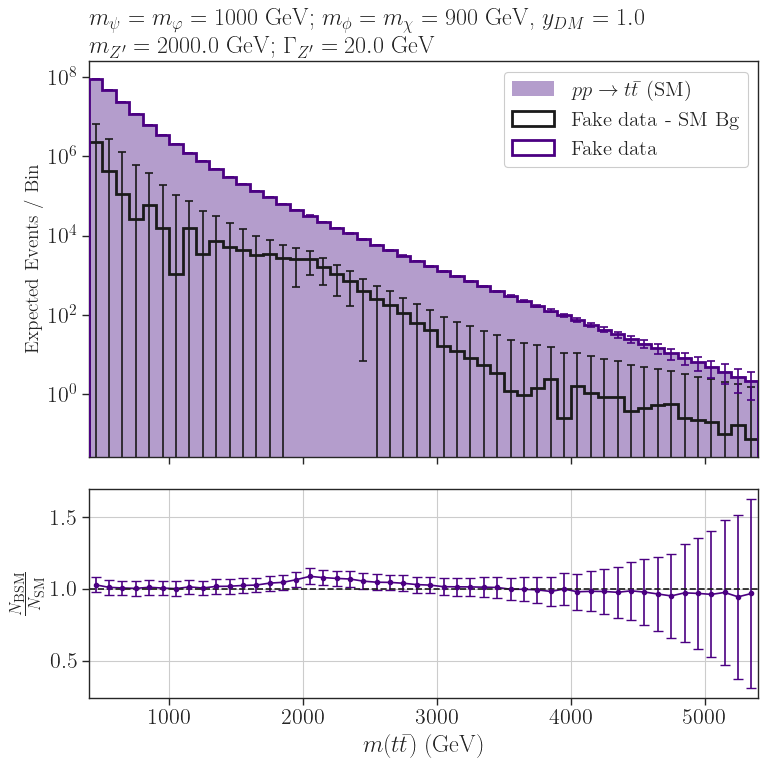

In [13]:

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']

    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)

    x = (bins[:-1] + bins[1:]) / 2.0
    bin_widths = np.diff(bins)

    ##############
    # Main Plot  #
    ##############

    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)

    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Multiply heights by lum_scale, and variance by lum_scale^2
        h_sm_total += h * lum_scale
        hErr_sm_total_sq += hErr_sq * (lum_scale**2)

    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)

    integral_sm = np.sum(h_sm_total/(n+1))
    h_sm = h_sm_total/(n+1)
    hErr_sm = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (sm_err*h_sm)**2)

    axarr[0].hist(
        bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, 
        color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step',
        linewidth=0, fill=True, zorder=0
    )

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    #y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 3.06822e+00}
    
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]

        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]

        color = get_color_by_mass(model, (mPsiT, mSDM))

        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 

        # Scale by luminosity!
        h_bsm_total = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_total_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2)* (lum_scale**2)

        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

       # axarr[0].hist(
        #    bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
        #    color=color, alpha=1.0, histtype='step', 
         #   linewidth=2, fill=False, zorder=3
        #)

    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""

    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Scale Z' by luminosity
        h_z_total += h * lum_scale
        hErr_z_total_sq += hErr_sq * (lum_scale**2)
        model_z = d['model']

    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]

        color_z = get_color_by_mass(model_z, (mPsiT, mSDM))

        integral_z = np.sum(h_z_total)
        h_z = h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq)

        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)

       # axarr[0].hist(
        #    bins[:-1], weights=np.abs(h_z), label=label_z, bins=bins,
        #    color=color_z, alpha=1.0, histtype='step', 
        #    linewidth=2, fill=False, zorder=3
        #)

    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # -------------------------------------------------------------
    # REALISTIC FAKE DATA ERROR BARS:
    # Since this is "data", the statistical uncertainty is just sqrt(N).
    # We add this Poisson variance to the Expected SM variance!
    # -------------------------------------------------------------
    
    stat_variance_obs = np.abs(N_obs) # sqrt(N)^2 = N

    bsm_hists.append(N_obs)
    bsm_errs.append(np.sqrt(stat_variance_obs ))
    
    bsm_labels.append('Fake Data')
    bsm_colors.append('indigo')

    
    bsm_hists.append(N_obs - h_sm)
    bsm_errs.append(np.sqrt(stat_variance_obs + hErr_sm**2))
    
    bsm_labels.append('Fake Data - SM Bg')
    bsm_colors.append('k')
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data - SM Bg', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_errs[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )

    axarr[0].hist(
        bins[:-1], weights=np.abs(N_obs), label='Fake data', bins=bins,
        color='indigo', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, np.abs(N_obs), yerr=np.sqrt(stat_variance_obs), color='indigo', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )

    

    ######################################################
    #  Chi-Squared Test (Accounting for ALL Uncertainties)
    ######################################################
    
    # 1. Define the Observation (Fake Data is the last item in bsm_hists)
    fake_obs = bsm_hists[-1] 
    
    # The statistical variance of the observation is just N_obs
    stat_variance_obs = np.abs(fake_obs) 
    
    # 2. Define the Hypotheses to test against
    hypotheses = [
        ("VLF", bsm_hists[0], bsm_errs[0]**2),
        ("Scalar", bsm_hists[1], bsm_errs[1]**2)
    ]
    if len(data_Z) > 0:
        hypotheses.append(("Z'", bsm_hists[2], bsm_errs[2]**2))
    
    # 3. Only use bins with enough events
    valid_bins = h_sm > 0
    
    print(f"\n--- Chi-Squared Test Results for mPsiT = {mPsiT} GeV ---")
    
    # FIX 3: Use a list to safely handle LaTeX and newlines
    chi2_annotation_lines = [r"$\chi^2$ / ndf (Significance):"]
    
    for name, hyp_hist, hyp_variance in hypotheses:
        O = fake_obs[valid_bins]
        E = hyp_hist[valid_bins]
        
        total_variance = stat_variance_obs[valid_bins] + hyp_variance[valid_bins]
        
        # Protect against dividing by zero if a bin has absolutely no variance
        safe_mask = total_variance > 0
        
        # FIX 2: ndf is strictly the number of tested bins (no minus 1)
        ndf = np.sum(safe_mask)
        
        if ndf > 0:
            chi2_val = np.sum((O[safe_mask] - E[safe_mask])**2 / total_variance[safe_mask])
            p_value = stats.chi2.sf(chi2_val, ndf)
            
            # FIX 1: Prevent negative sigmas for perfect fits
            if p_value >= 0.5:
                z_score = 0.0
            else:
                z_score = stats.norm.isf(max(p_value, 1e-15))
        else:
            chi2_val, p_value, z_score = 0.0, 1.0, 0.0
            
        print(f"vs {name:12s} -> Chi2 = {chi2_val:.1f} | p-value = {p_value:.2e} | Z = {z_score:.2f} sigma")
        
        # Safely format for plot annotation
        chi2_annotation_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")
        
    print("-" * 65 + "\n")
    
    # Join the lines with actual newline characters
    chi2_annotation_text = "\n".join(chi2_annotation_lines)

   ############
    # SUBPLOT  #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        # 1. Grab the specific Fake Data arrays (index -2)
        h_target = bsm_hists[-2]
        err_target = bsm_errs[-2]

        # 2. Calculate the ratio array
        ratio = np.nan_to_num(h_target / h_sm)

        # 3. Calculate relative errors
        err_target_rel = np.nan_to_num(err_target / h_target)
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)

        # 4. Propagate the final ratio error
        ratio_err = np.abs(ratio) * np.sqrt(err_target_rel**2 + err_sm_rel**2)

    # 5. Plot the single array directly (no loops needed!)
    # (bsm_colors[-2] is 'indigo' and bsm_labels[-2] is 'Fake Data')
    color_fake = bsm_colors[-2]
    label_fake = bsm_labels[-2]

    axarr[1].errorbar(x, ratio, yerr=ratio_err, color=color_fake, fmt='o', ms=3, capsize=3.5, label=label_fake)
    axarr[1].plot(x, ratio, color=color_fake)

    

   
    
    #################
    # Plot configs  #
    #################

    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') %
        (mPsiT, mSDM, yDM, mZp, 20.0),
        loc='left'
    )
    axarr[0].set_yscale('log')
    
    # CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
    axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot
    axarr[1].axhline(y=1, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    #axarr[1].set_yscale('symlog', linthresh=0.0001)
    #axarr[1].set_ylim([-0.003, 0.3])

    minor_tick_locations = np.concatenate((
        np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
        np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
    ))
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    #plt.savefig('Dists_comparison_interference.png')
    plt.show()

# Working with the BSM leading order contribution

\n--- Chi-Squared Test Results for mPsiT = 1000.0 GeV ---
vs  VLF         -> Chi2 = 1347615.3 | p-value = 0.00e+00 | Z = 7.94 sigma
vs  Scalar      -> Chi2 = 450895.2 | p-value = 0.00e+00 | Z = 7.94 sigma
vs Z'           -> Chi2 = 3008407.0 | p-value = 0.00e+00 | Z = 7.94 sigma
-----------------------------------------------------------------



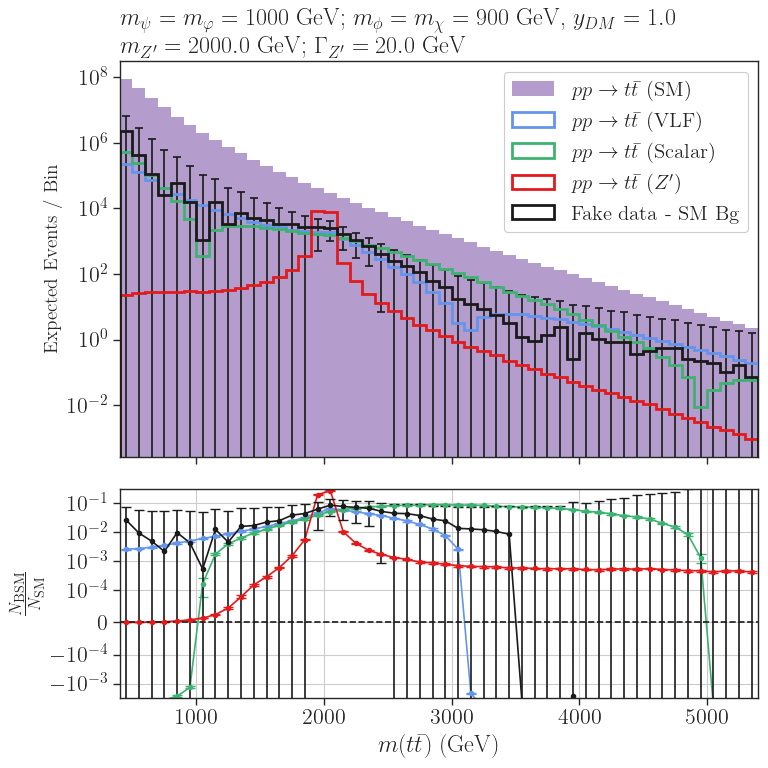

In [14]:

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']

    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)

    x = (bins[:-1] + bins[1:]) / 2.0
    bin_widths = np.diff(bins)

    ##############
    # Main Plot  #
    ##############

    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)

    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Multiply heights by lum_scale, and variance by lum_scale^2
        h_sm_total += h * lum_scale
        hErr_sm_total_sq += hErr_sq * (lum_scale**2)

    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)

    integral_sm = np.sum(h_sm_total/(n+1))
    h_sm = h_sm_total/(n+1)
    hErr_sm = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (sm_err*h_sm)**2)

    axarr[0].hist(
        bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, 
        color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step',
        linewidth=0, fill=True, zorder=0
    )

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 3.06822e+00}
    
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]

        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]

        color = get_color_by_mass(model, (mPsiT, mSDM))

        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 

        # Scale by luminosity!
        h_bsm_total = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_total_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2)* (lum_scale**2)

        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

        axarr[0].hist(
            bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
            color=color, alpha=1.0, histtype='step', 
            linewidth=2, fill=False, zorder=3
        )

    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""

    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Scale Z' by luminosity
        h_z_total += h * lum_scale
        hErr_z_total_sq += hErr_sq * (lum_scale**2)
        model_z = d['model']

    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]

        color_z = get_color_by_mass(model_z, (mPsiT, mSDM))

        integral_z = np.sum(h_z_total)
        h_z = h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq)

        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)

        axarr[0].hist(
            bins[:-1], weights=np.abs(h_z), label=label_z, bins=bins,
            color=color_z, alpha=1.0, histtype='step', 
            linewidth=2, fill=False, zorder=3
        )

    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # -------------------------------------------------------------
    # REALISTIC FAKE DATA ERROR BARS:
    # Since this is "data", the statistical uncertainty is just sqrt(N).
    # We add this Poisson variance to the Expected SM variance!
    # -------------------------------------------------------------
    stat_variance_obs = np.abs(N_obs) # sqrt(N)^2 = N
    
    bsm_hists.append(N_obs - h_sm)
    bsm_errs.append(np.sqrt(stat_variance_obs + hErr_sm**2))
    sqrt_N = np.sqrt(N_obs)
    sm_sys = hErr_sm
    
    bsm_labels.append('Fake Data - SM Bg')
    bsm_colors.append('k')
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data - SM Bg', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_errs[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )

    ############
    # SUBPLOT  #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        ratio = raw_ratio

        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)

        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    for k, r in enumerate(ratio):
        axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k])

    
    

    import scipy.stats as stats

    ######################################################
    #  Chi-Squared Test (Accounting for ALL Uncertainties)
    ######################################################
    
    # 1. Define the Observation (Fake Data is the last item in bsm_hists)
    # NOTE: Ensure your fake data here is the TOTAL observation (SM + Signal), 
    # not the background-subtracted version.
    fake_obs = bsm_hists[-1] 
    
    # The statistical variance of the observation is just N_obs
    stat_variance_obs = np.abs(fake_obs) 
    
    # 2. Define the Hypotheses to test against
    hypotheses = [
        (" VLF", bsm_hists[0], bsm_errs[0]**2),
        (" Scalar", bsm_hists[1], bsm_errs[1]**2)
    ]
    if len(data_Z) > 0:
        hypotheses.append(("Z'", bsm_hists[2], bsm_errs[2]**2))
    
    # 3. Only use bins with enough events (e.g., Expected SM > 0) to avoid division by zero
    valid_bins = h_sm > 0
    degrees_of_freedom = np.sum(valid_bins) - 1 # n_bins - 1
    
    print(rf"\n--- Chi-Squared Test Results for mPsiT = {mPsiT} GeV ---")
    
    chi2_annotation_text = r"$\chi^2$ / ndf (Significance):\n"
    
    for name, hyp_hist, hyp_variance in hypotheses:
        # Get the valid bins for Data and Hypothesis
        O = fake_obs[valid_bins]
        E = hyp_hist[valid_bins]
        
        # Total Variance = Variance(Data) + Variance(Hypothesis)
        # Hypothesis variance already contains the 5% systematic + MC stats!
        total_variance = stat_variance_obs[valid_bins] + hyp_variance[valid_bins]
        
        # Calculate Chi-Squared
        chi2_val = np.sum((O - E)**2 / total_variance)
        
        # Calculate p-value (probability of seeing this deviation by chance)
        p_value = stats.chi2.sf(chi2_val, degrees_of_freedom)
        
        # Convert p-value to Z-score (Sigmas)
        # If p-value is extremely small (perfect rejection), sf can hit 0.0. 
        # We clip it to avoid infinity.
        p_value_clipped = max(p_value, 1e-15)
        z_score = stats.norm.isf(p_value_clipped)
        
        print(rf"vs {name:12s} -> Chi2 = {chi2_val:.1f} | p-value = {p_value:.2e} | Z = {z_score:.2f} sigma")
        
        # Format for plot annotation
        chi2_annotation_text += rf"{name}: {chi2_val:.1f}/{degrees_of_freedom} ({z_score:.1f}$\sigma$)\n"
        
    print("-" * 65 + "\n")

   
    
    #################
    # Plot configs  #
    #################

    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') %
        (mPsiT, mSDM, yDM, mZp, 20.0),
        loc='left'
    )
    axarr[0].set_yscale('log')
    
    # CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
    axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh=0.0001)
    axarr[1].set_ylim([-0.003, 0.3])

    minor_tick_locations = np.concatenate((
        np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
        np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
    ))
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    #plt.savefig('Dists_comparison_interference.png')
    plt.show()

11 2
\n--- Chi-Squared Test Results for mPsiT = 1000.0 GeV ---
vs  VLF         -> Chi2 = 966806.0 | p-value = 0.00e+00 | Z = 7.94 sigma
vs  Scalar      -> Chi2 = 33788.7 | p-value = 0.00e+00 | Z = 7.94 sigma
vs Z'           -> Chi2 = 1239876.7 | p-value = 0.00e+00 | Z = 7.94 sigma
-----------------------------------------------------------------



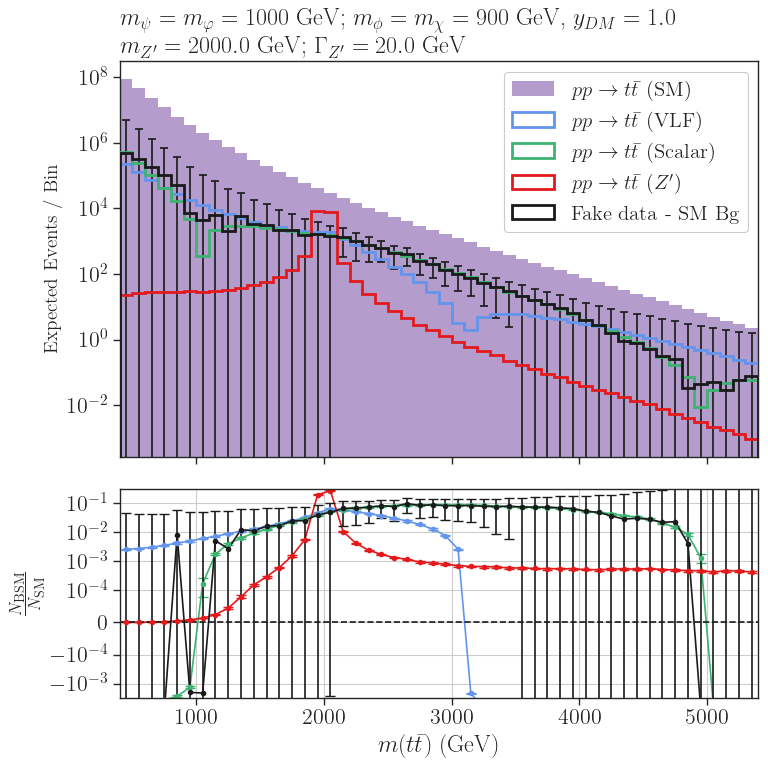

In [136]:

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']

    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)

    x = (bins[:-1] + bins[1:]) / 2.0
    bin_widths = np.diff(bins)

    ##############
    # Main Plot  #
    ##############

    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)

    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Multiply heights by lum_scale, and variance by lum_scale^2
        h_sm_total += h * lum_scale
        hErr_sm_total_sq += hErr_sq * (lum_scale**2)

    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)

    integral_sm = np.sum(h_sm_total/(n+1))
    h_sm = h_sm_total/(n+1)
    hErr_sm = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (sm_err*h_sm)**2)
    hErr_sm_mc = np.sqrt(hErr_sm_total_sq/((n+1)**2) )
    hErr_sm_sys = np.sqrt((sm_err*h_sm)**2)

    axarr[0].hist(
        bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, 
        color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step',
        linewidth=0, fill=True, zorder=0
    )

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 3.06822e+00}
    
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]

        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]

        color = get_color_by_mass(model, (mPsiT, mSDM))

        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 

        # Scale by luminosity!
        h_bsm_total = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_total_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2)* (lum_scale**2)

        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

        axarr[0].hist(
            bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
            color=color, alpha=1.0, histtype='step', 
            linewidth=2, fill=False, zorder=3
        )

    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""

    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Scale Z' by luminosity
        h_z_total += h * lum_scale
        hErr_z_total_sq += hErr_sq * (lum_scale**2)
        model_z = d['model']

    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]

        color_z = get_color_by_mass(model_z, (mPsiT, mSDM))

        integral_z = np.sum(h_z_total)
        h_z = h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq)

        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)

        axarr[0].hist(
            bins[:-1], weights=np.abs(h_z), label=label_z, bins=bins,
            color=color_z, alpha=1.0, histtype='step', 
            linewidth=2, fill=False, zorder=3
        )

    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake_sig = np.zeros(len(bins)-1)
    hErr_fake_sig = np.zeros(len(bins)-1)
    h_fake_sm = np.zeros(len(bins)-1)
    hErr_fake_sm = np.zeros(len(bins)-1)
    n_sm = 0
    n = 0
    for d in d_fake:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        if d['model'] == 'SM':
            h_fake_sm += h
            hErr_fake_sm += hErr_sq
            n_sm+=1
        else:
            h_fake_sig += fake_scale_factor * h
            hErr_fake_sig += (fake_scale_factor**2) * hErr_sq
            n+=1
    print(n_sm,n)
    h_fake = h_fake_sig/(n/2) + h_fake_sm/n_sm 
    hErr_fake = np.sqrt(hErr_fake_sig/((n/2)**2) + hErr_fake_sm/(n_sm**2))
        
    # The total expected observation of the fake data
    N_obs = h_fake * lum_scale
    
    # -------------------------------------------------------------
    # REALISTIC FAKE DATA ERROR BARS:
    # Since this is "data", the statistical uncertainty is just sqrt(N).
    # We add this Poisson variance to the Expected SM variance!
    # -------------------------------------------------------------
    stat_variance_obs = np.abs(N_obs) # sqrt(N)^2 = N
    
    bsm_hists.append(N_obs - h_sm)
    bsm_errs.append(np.sqrt(stat_variance_obs + hErr_sm**2))
    sqrt_N = np.sqrt(N_obs)
    sm_sys = hErr_sm
    
    bsm_labels.append('Fake Data - SM Bg')
    bsm_colors.append('k')
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data - SM Bg', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_errs[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )

    ############
    # SUBPLOT  #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        ratio = raw_ratio

        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)

        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    for k, r in enumerate(ratio):
        axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k])

    
    

    import scipy.stats as stats

    ######################################################
    #  Chi-Squared Test (Accounting for ALL Uncertainties)
    ######################################################
    
    # 1. Define the Observation (Fake Data is the last item in bsm_hists)
    # NOTE: Ensure your fake data here is the TOTAL observation (SM + Signal), 
    # not the background-subtracted version.
    fake_obs = bsm_hists[-1] 
    
    # The statistical variance of the observation is just N_obs
    stat_variance_obs = np.abs(fake_obs) 
    
    # 2. Define the Hypotheses to test against
    hypotheses = [
        (" VLF", bsm_hists[0], bsm_errs[0]**2),
        (" Scalar", bsm_hists[1], bsm_errs[1]**2)
    ]
    if len(data_Z) > 0:
        hypotheses.append(("Z'", bsm_hists[2], bsm_errs[2]**2))
    
    # 3. Only use bins with enough events (e.g., Expected SM > 0) to avoid division by zero
    valid_bins = h_sm > 0
    degrees_of_freedom = np.sum(valid_bins) - 1 # n_bins - 1
    
    print(rf"\n--- Chi-Squared Test Results for mPsiT = {mPsiT} GeV ---")
    
    chi2_annotation_text = r"$\chi^2$ / ndf (Significance):\n"
    
    for name, hyp_hist, hyp_variance in hypotheses:
        # Get the valid bins for Data and Hypothesis
        O = fake_obs[valid_bins]
        E = hyp_hist[valid_bins]
        
        # Total Variance = Variance(Data) + Variance(Hypothesis)
        # Hypothesis variance already contains the 5% systematic + MC stats!
        total_variance = stat_variance_obs[valid_bins] + hyp_variance[valid_bins]
        
        # Calculate Chi-Squared
        chi2_val = np.sum((O - E)**2 / total_variance)
        
        # Calculate p-value (probability of seeing this deviation by chance)
        p_value = stats.chi2.sf(chi2_val, degrees_of_freedom)
        
        # Convert p-value to Z-score (Sigmas)
        # If p-value is extremely small (perfect rejection), sf can hit 0.0. 
        # We clip it to avoid infinity.
        p_value_clipped = max(p_value, 1e-15)
        z_score = stats.norm.isf(p_value_clipped)
        
        print(rf"vs {name:12s} -> Chi2 = {chi2_val:.1f} | p-value = {p_value:.2e} | Z = {z_score:.2f} sigma")
        
        # Format for plot annotation
        chi2_annotation_text += rf"{name}: {chi2_val:.1f}/{degrees_of_freedom} ({z_score:.1f}$\sigma$)\n"
        
    print("-" * 65 + "\n")

   
    
    #################
    # Plot configs  #
    #################

    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') %
        (mPsiT, mSDM, yDM, mZp, 20.0),
        loc='left'
    )
    axarr[0].set_yscale('log')
    
    # CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
    axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh=0.0001)
    axarr[1].set_ylim([-0.003, 0.3])

    minor_tick_locations = np.concatenate((
        np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
        np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
    ))
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    #plt.savefig('Dists_comparison_interference.png')
    plt.show()

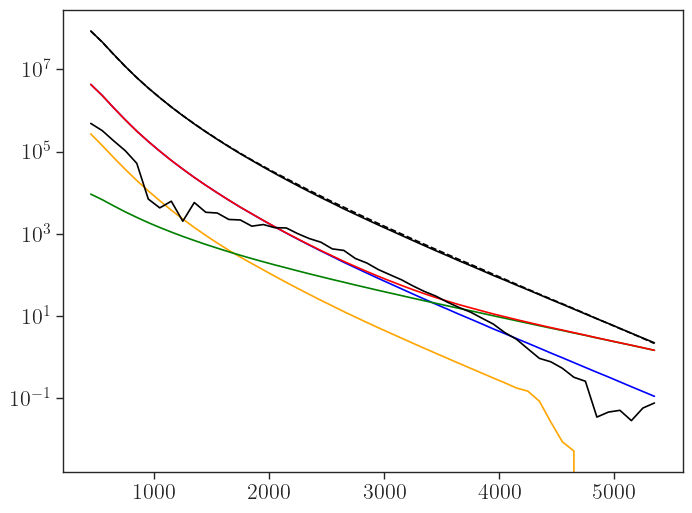

In [137]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, sm_sys, 'blue')
ax.plot(x, hErr_sm_mc, 'orange')
ax.plot(x,sqrt_N, 'green')
ax.plot(x, np.sqrt(sqrt_N**2 + sm_sys**2), 'red')
ax.plot(x,np.abs(bsm_hists[-1]), 'black' )
ax.plot(x,h_sm, 'black' )
ax.plot(x,N_obs, 'black', ls = '--' )
ax.set_yscale('log')
plt.show()

Peak bin starts at: 2000.0


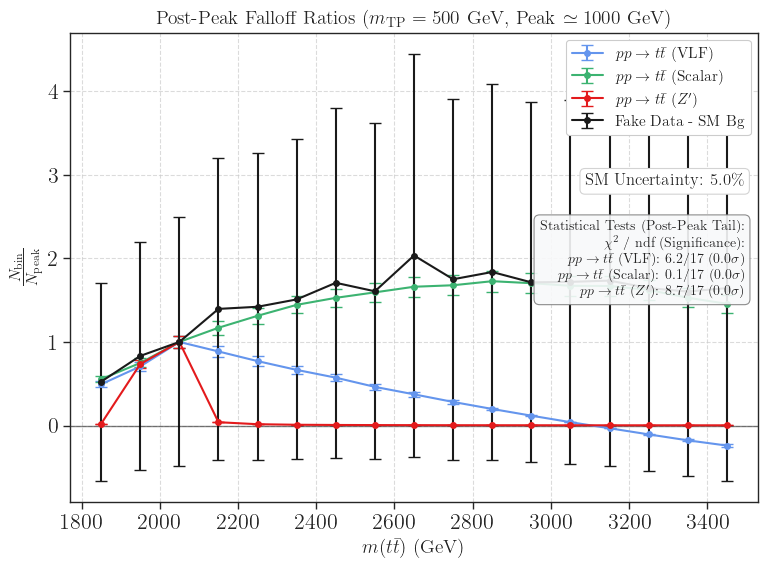

In [138]:

mTP = 1000.0 #GeV
n_bp = 2
n_ap =15
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(f"Peak bin starts at: {bins[b_peak]}")

ratios = []
ratios_err = []
frac_peak, frac_bins = [], []
# Computing the ratios
for i, h in enumerate(raw_ratio):
    aux = []
    err = []
    # Loop starts at b_peak, but we will ignore the 0th element in the stats test!
    frac_peak, frac_bins = [], []
    for j in range(b_peak-n_bp, b_peak + n_ap):
        A = h[j]
        B = h[b_peak]
        errA = ratio_err[i][j]
        errB = ratio_err[i][b_peak]
        
        aux.append(A / B)
        
        # Safe propagation: avoids dividing by zero if the tail crosses zero
        safe_err =abs(aux[-1]) * np.sqrt((errA / A)**2 + ( errB / B)**2)
        frac_bins.append(errA/A)
        frac_peak.append(errB/B)

        
        #print(i, safe_err/aux[-1])
        err.append(safe_err)
        
    ratios.append(aux)
    ratios_err.append(err)

# ==========================================
# Statistical Tests (Fake Data vs Theory)
# ==========================================
# Assuming Fake Data is the LAST element in your lists
fake_ratio = np.array(ratios[-1])
fake_ratio_err = np.array(ratios_err[-1])

# We slice [1:] to skip the b_peak itself 
valid_fake_ratio = fake_ratio
valid_fake_err = fake_ratio_err

stats_lines = [
    "Statistical Tests (Post-Peak Tail):",
    r"$\chi^2$ / ndf (Significance):"
]

for k in range(len(ratios) - 1): # Skip the last element (which is Fake Data itself)
    hyp_ratio = np.array(ratios[k])
    hyp_err = np.array(ratios_err[k])
    name = bsm_labels[k]
    

    total_variance = valid_fake_err**2 + hyp_err**2
    
    # Calculate Chi2
    valid_mask = total_variance > 0
    ndf = np.sum(valid_mask)
    
    if ndf > 0:
        chi2_val = np.sum((valid_fake_ratio[valid_mask] - hyp_ratio[valid_mask])**2 / total_variance[valid_mask])
        p_value = stats.chi2.sf(chi2_val, ndf)
        
        # PYTHON FIX: Cap the p-value at 0.5 to prevent stats.norm.isf from outputting -inf
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-15))
    else:
        chi2_val, z_score = 0.0, 0.0
    
    stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")



# Join the list into a single safe string
stats_text = "\n".join(stats_lines)


# ==========================================
# Plotting the ratios for each model
# ==========================================

# Calculate the bin centers for the x-axis
x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak-n_bp, b_peak + n_ap)]

fig, ax = plt.subplots(figsize=(8, 6))

# Loop over the calculated ratios to plot them
for k in range(len(ratios)):
    label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
    color = bsm_colors[k] if 'bsm_colors' in locals() else None
    
    ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                capsize=4, label=label, color=color, markersize=4, linewidth=1.5)


# Formatting the plot to match the style of your previous physics plots
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=16)
ax.set_title(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 500$ GeV, Peak $\simeq 1000$ GeV)', fontsize=14)

# Adding a horizontal line at 0 so you can clearly see the negative interference crossing!
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.grid(True, linestyle='--', alpha=0.7)
#ax.set_yscale('log')

# --- ANNOTATIONS ---

# Place the Legend
ax.legend(fontsize=11, framealpha=1.0, loc='upper right')

# Place the SM Uncertainty Box safely using .format()
sm_text = r"SM Uncertainty: {:.1f}\%".format(sm_err * 100)
ax.text(0.98, 0.70, sm_text, 
        transform=ax.transAxes,      
        fontsize=12, 
        verticalalignment='top',     
        horizontalalignment='right', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

# Place the Statistics Box below the SM Uncertainty Box
ax.text(0.98, 0.60, stats_text, 
        transform=ax.transAxes,      
        fontsize=10, 
        verticalalignment='top',         # Anchor to the top edge 
        horizontalalignment='right',     # Anchor to the right edge (aligns with the boxes above it)
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('Post_Peak_Falloff.png', dpi=300)
plt.show()

Peak bin starts at: 2000.0


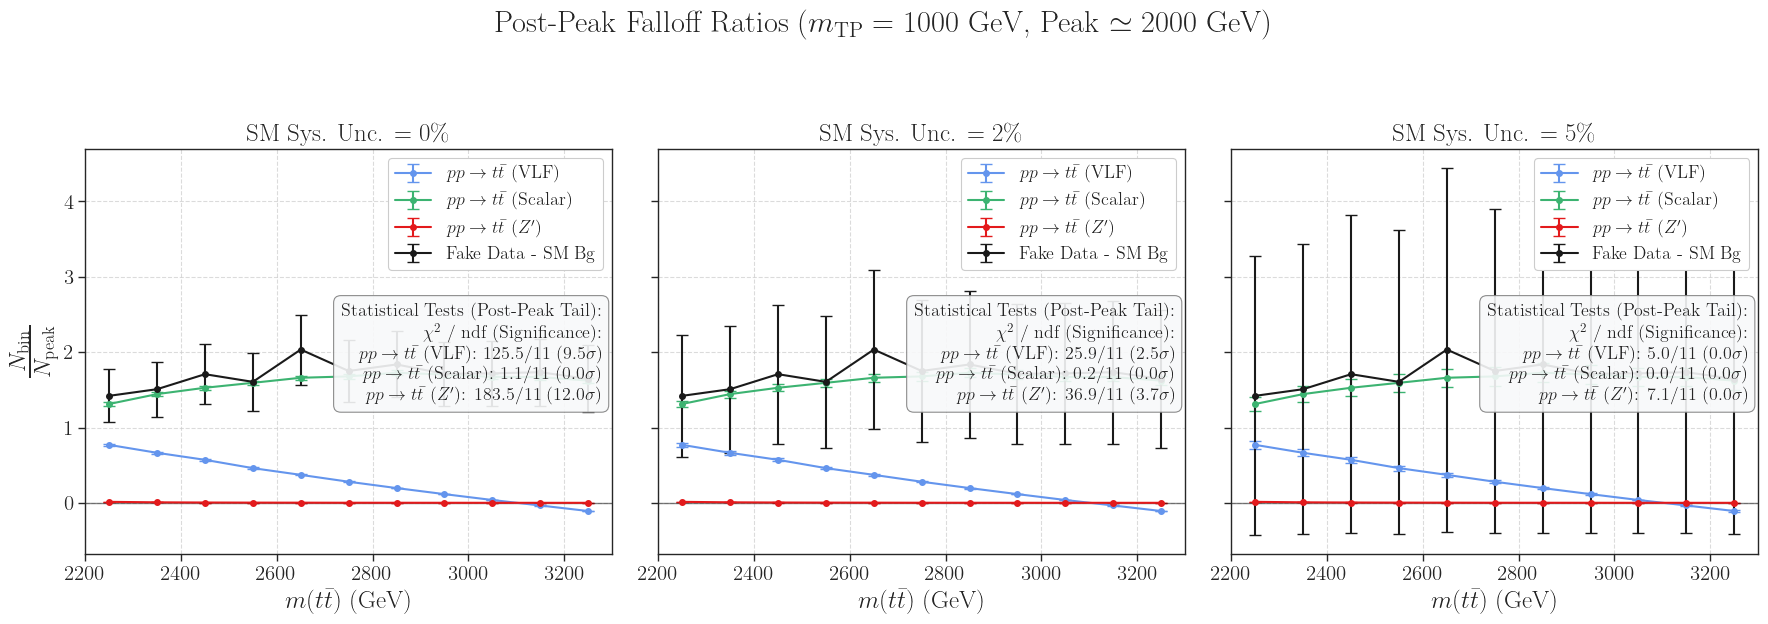


--- Significance Dictionary ---
{'$p p \\to t \\bar{t}$ (VLF)': {0.0: np.float64(9.46924867866353), 0.02: np.float64(2.468670998752896), 0.05: 0.0}, '$p p \\to t \\bar{t}$ (Scalar)': {0.0: 0.0, 0.02: 0.0, 0.05: 0.0}, '$p p \\to t \\bar{t}$ ($Z^\\prime$)': {0.0: np.float64(11.994628258161109), 0.02: np.float64(3.6756502012571133), 0.05: 0.0}}


In [139]:
mTP = 1000.0 #GeV
n_bp = -2
n_ap = 13
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(f"Peak bin starts at: {bins[b_peak]}")

# Define the SM systematic uncertainties we want to plot
sm_errs_list = [0.0, 0.02, 0.05]

# --- ADDED: Initialize the dictionary to hold our results ---
model_significances = {}

# Create a 1x3 grid of subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# We will loop over the systematic uncertainties and fill each subplot
for idx, current_sm_err in enumerate(sm_errs_list):
    ax = axes[idx]
    
    # -----------------------------------------------------------------
    # 1. Recalculate Fake Data Error for this specific systematic
    # -----------------------------------------------------------------
    hErr_sm_current = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (current_sm_err * h_sm)**2)
    fake_err_current = np.sqrt(stat_variance_obs + hErr_sm_current**2)
    bsm_errs[-1] = fake_err_current
    err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm_current / h_sm)

    ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    # -----------------------------------------------------------------
    # 2. Compute Ratios for this systematic
    # -----------------------------------------------------------------
    ratios = []
    ratios_err = []
    for i_hist, h in enumerate(raw_ratio):
        aux = []
        err = []
        for j in range(b_peak-n_bp, b_peak + n_ap):
            A = h[j]
            B = h[b_peak]
            errA = ratio_err[i_hist][j]
            errB = ratio_err[i_hist][b_peak]
            
            val = A / B if B != 0 else 0
            aux.append(val)
            
            if A != 0 and B != 0:
                safe_err = abs(val) * np.sqrt((errA / A)**2 + (errB / B)**2)
            else:
                safe_err = 0.0
            err.append(safe_err)
            
        ratios.append(aux)
        ratios_err.append(err)

    # -----------------------------------------------------------------
    # 3. Statistical Tests
    # -----------------------------------------------------------------
    fake_ratio = np.array(ratios[-1])
    fake_ratio_err = np.array(ratios_err[-1])
    
    valid_fake_ratio = fake_ratio
    valid_fake_err = fake_ratio_err

    stats_lines = [
        "Statistical Tests (Post-Peak Tail):",
        r"$\chi^2$ / ndf (Significance):"
    ]

    for k in range(len(ratios) - 1): # Skip the last element (Fake Data)
        hyp_ratio = np.array(ratios[k])
        hyp_err = np.array(ratios_err[k])
        name = bsm_labels[k]
        
        total_variance = valid_fake_err**2 + hyp_err**2
        
        valid_mask = total_variance > 0
        ndf = np.sum(valid_mask)
        
        if ndf > 0:
            chi2_val = np.sum((valid_fake_ratio[valid_mask] - hyp_ratio[valid_mask])**2 / total_variance[valid_mask])
            p_value = stats.chi2.sf(chi2_val, ndf)
            
            if p_value >= 0.5:
                z_score = 0.0
            else:
                z_score = stats.norm.isf(max(p_value, 1e-55))
        else:
            chi2_val, z_score = 0.0, 0.0
        
        # --- ADDED: Save the results directly into our dictionary ---
        clean_name = name.strip() # Remove any accidental leading/trailing spaces
        if clean_name not in model_significances:
            model_significances[clean_name] = {} # Create a sub-dictionary for the model if it doesn't exist
            
        model_significances[clean_name][current_sm_err] = z_score#hi2_val/ndf
        
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    stats_text = "\n".join(stats_lines)

    # -----------------------------------------------------------------
    # 4. Plotting
    # -----------------------------------------------------------------
    x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak-n_bp, b_peak + n_ap)]

    for k in range(len(ratios)):
        label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
        color = bsm_colors[k] if 'bsm_colors' in locals() else None
        
        ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                    capsize=4, label=label, color=color, markersize=4, linewidth=1.5)
    
    # Increase axis label sizes
    ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=18)
    if idx == 0:
        ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=24)
        
    # Increase subplot title size
    ax.set_title(r'SM Sys. Unc. = {:.0f}\%'.format(current_sm_err * 100), fontsize=18)
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Make the tick labels (numbers on the axes) larger
    ax.tick_params(axis='both', which='major', labelsize=15)

    # Annotations
    ax.legend(fontsize=13, framealpha=1.0, loc='upper right')

    ax.text(0.98, 0.62, stats_text, 
            transform=ax.transAxes,      
            fontsize=13,
            verticalalignment='top',         
            horizontalalignment='right',     
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

fig.suptitle(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=22, y=1.05)

plt.tight_layout()
plt.savefig('Post_Peak_Falloff_SideBySide.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------
# 5. Accessing your saved variable
# -----------------------------------------------------------------
print("\n--- Significance Dictionary ---")
print(model_significances)

# Example of how to access a specific value later:
# vlf_5percent_sig = model_significances.get('VLF', {}).get(0.05, 0.0)

ValueError: x and y must have same first dimension, but have shapes (11,) and (17,)

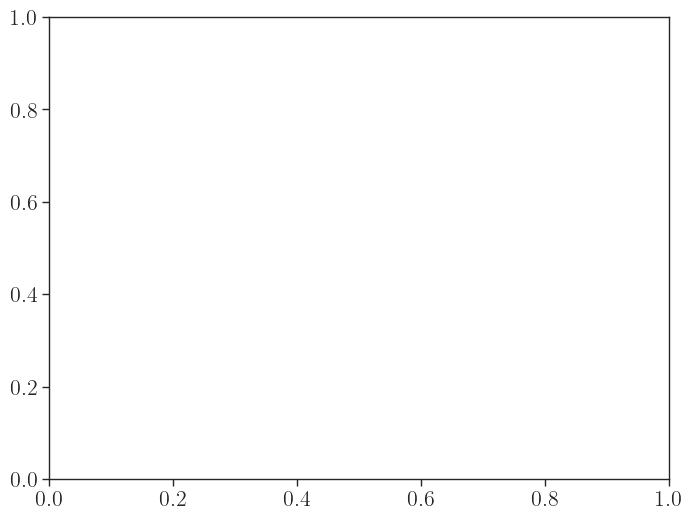

In [140]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x[b_peak-n_bp:b_peak+n_ap], np.abs(frac_peak), 'blue')
ax.plot(x[b_peak-n_bp:b_peak+n_ap],np.abs(frac_bins), 'green')
ax.plot(x[b_peak-n_bp:b_peak+n_ap], np.abs(fake_ratio),'red' )
ax.plot(x[b_peak-n_bp:b_peak+n_ap], np.abs(fake_ratio) * np.sqrt(np.array(frac_peak)**2 + np.array(frac_bins)**2),'black' )
ax.set_yscale('log')
plt.show()

### Checking the number of events condition

In [ ]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) 

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()



# Working with the SM + BSM LO terms

11 2


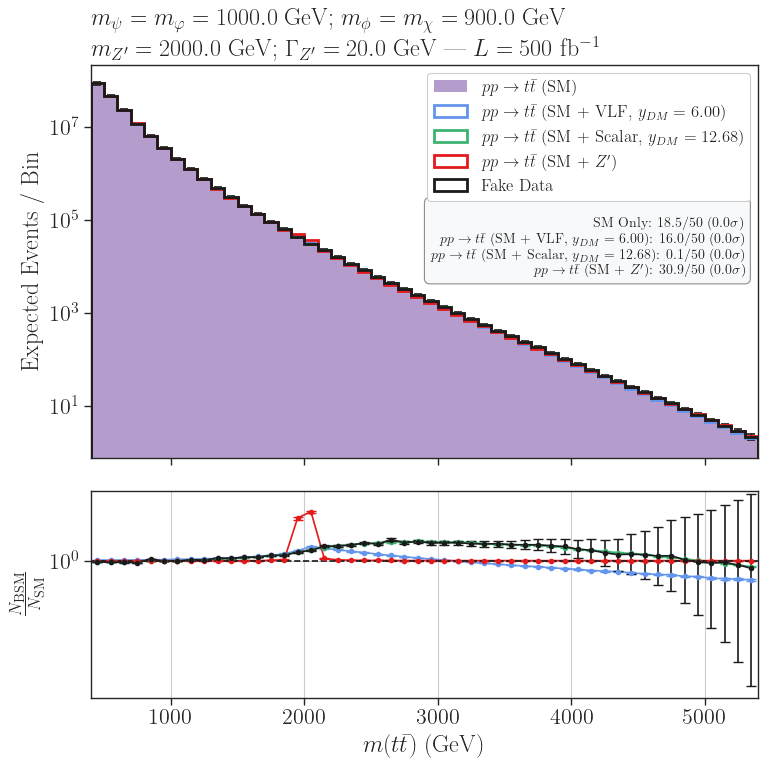

In [143]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.05 # 5% SM Systematic Uncertainty

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Extract final Expected SM Events
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    
    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 1.000e+00}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) # Error includes SM systematics
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

        # APPLY LUMINOSITY SCALING
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)
                      
        # --- Propagating Error for Z' Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake_sig = np.zeros(len(bins)-1)
    hErr_fake_sig = np.zeros(len(bins)-1)
    h_fake_sm = np.zeros(len(bins)-1)
    hErr_fake_sm = np.zeros(len(bins)-1)
    n_sm = 0
    n = 0
    for d in d_fake:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        if d['model'] == 'SM':
            h_fake_sm += h
            hErr_fake_sm += hErr_sq
            n_sm+=1
        else:
            h_fake_sig += fake_scale_factor * h
            hErr_fake_sig += (fake_scale_factor**2) * hErr_sq
            n+=1
    print(n_sm,n)
    h_fake = h_fake_sig/(n/2) + h_fake_sm/n_sm 
    hErr_fake = np.sqrt(hErr_fake_sig/((n/2)**2) + hErr_fake_sm/(n_sm**2))
        
    # The total expected observation of the fake data
    N_obs = h_fake * lum_scale
    
    # -------------------------------------------------------------
    # REALISTIC FAKE DATA ERROR BARS:
    # Since this is "data", the statistical uncertainty is just sqrt(N).
    # We add this Poisson variance to the Expected SM variance!
    # -------------------------------------------------------------
    stat_variance_obs = np.abs(N_obs) # sqrt(N)^2 = N
    
    bsm_hists.append(N_obs )
    bsm_histsErr.append(np.sqrt(stat_variance_obs + (sm_err*N_obs)**2))
    sqrt_N = np.sqrt(N_obs)
    sm_sys = hErr_sm
    
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label=bsm_labels[-1], bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_errs[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )


    # --- Propagating error for Ratio ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs / h_sm
        err_bsm_stat = np.sqrt(bsm_histsErr[-1])
        
        ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    # Dynamically build hypotheses list containing: (Name, Hist, Error)
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # Ensure we only use valid bins
    valid_mask = (h_sm > 0)
    ndf = np.sum(valid_mask)
    
    stats_lines = [""]
    
  
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        
        # Total Variance = Var(FakeData) + Var(Hypothesis)
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        
        # Calculate Chi2 (only where variance > 0 to be safe)
        safe_variance_mask = total_variance > 0
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        
        # Calculate Significance
        p_value = stats.chi2.sf(chi2_val, ndf)
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-55))
            
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    # Combine into one text string
    stats_text = "\n".join(stats_lines)

    # Place the stats text box on the plot
    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, 
                  verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
    ############
    #  SUBPLOT #
    ############
    
    for k, r in enumerate(bsm_ratios):
        axarr[1].errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    axarr[1].axhline(y=1.0, color='k', linestyle='--') 
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    #axarr[1].set_yticks(np.arange(0.95,1.2, 0.05))
    axarr[1].set_yscale('symlog', linthresh = 1.2)
    
    plt.tight_layout()
    #plt.savefig('Dists_comparison.png')
    plt.show()

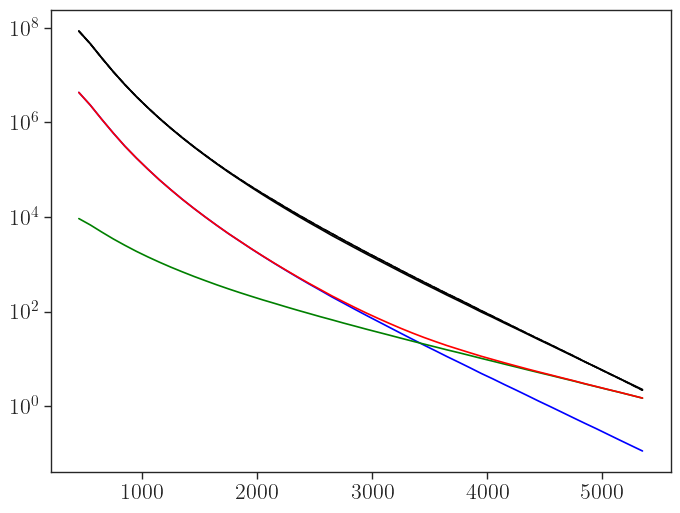

In [144]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, sm_sys, 'blue')
ax.plot(x,sqrt_N, 'green')
ax.plot(x, np.sqrt(sqrt_N**2 + sm_sys**2), 'red')
ax.plot(x,bsm_hists[-1], 'black' )
ax.plot(x,h_sm, 'black' )
ax.plot(x,N_obs, 'black', ls = '--' )
ax.set_yscale('log')
plt.show()

In [ ]:
mTP = 1000.0 #GeV
n_bp = -2
n_ap = 34
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(f"Peak bin starts at: {bins[b_peak]}")

# Define the SM systematic uncertainties we want to plot
sm_errs_list = [0.0, 0.02, 0.05]

# --- ADDED: Initialize the dictionary to hold our results ---
model_significances_sm_signal = {}

# Create a 1x3 grid of subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# We will loop over the systematic uncertainties and fill each subplot
for idx, current_sm_err in enumerate(sm_errs_list):
    ax = axes[idx]
    
    # -----------------------------------------------------------------
    # 1. Recalculate Fake Data Error for this specific systematic
    # -----------------------------------------------------------------
    hErr_sm_current = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (current_sm_err * h_sm)**2)
    fake_err_current = np.sqrt(stat_variance_obs + hErr_sm_current**2)
    bsm_histsErr[-1] = fake_err_current
    print(len(bsm_errs), len(bsm_hists))
    err_bsm_rel = np.nan_to_num(np.array(bsm_histsErr) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm_current / h_sm)

    bsm_ratio_errs = np.abs(bsm_ratios) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    # -----------------------------------------------------------------
    # 2. Compute Ratios for this systematic
    # -----------------------------------------------------------------
    ratios = []
    ratios_err = []
    for i_hist, h in enumerate(bsm_ratios):
        aux = []
        err = []
        for j in range(b_peak-n_bp, b_peak + n_ap):
            A = h[j]
            B = h[b_peak]
            errA = bsm_ratio_errs[i_hist][j]
            errB = bsm_ratio_errs[i_hist][b_peak]
            
            val = A / B if B != 0 else 0
            aux.append(val)
            
            if A != 0 and B != 0:
                safe_err = abs(val) * np.sqrt((errA / A)**2 + (errB / B)**2)
            else:
                safe_err = 0.0
            err.append(safe_err)
            
        ratios.append(aux)
        ratios_err.append(err)

    # -----------------------------------------------------------------
    # 3. Statistical Tests
    # -----------------------------------------------------------------
    fake_ratio = np.array(ratios[-1])
    fake_ratio_err = np.array(ratios_err[-1])
    
    valid_fake_ratio = fake_ratio
    valid_fake_err = fake_ratio_err

    stats_lines = [
        "Statistical Tests (Post-Peak Tail):",
        r"$\chi^2$ / ndf (Significance):"
    ]

    for k in range(len(ratios) - 1): # Skip the last element (Fake Data)
        hyp_ratio = np.array(ratios[k])
        hyp_err = np.array(ratios_err[k])
        name = bsm_labels[k]
        
        total_variance = valid_fake_err**2 + hyp_err**2
        
        valid_mask = total_variance > 0
        ndf = np.sum(valid_mask)
        
        if ndf > 0:
            chi2_val = np.sum((valid_fake_ratio[valid_mask] - hyp_ratio[valid_mask])**2 / total_variance[valid_mask])
            p_value = stats.chi2.sf(chi2_val, ndf)
            
            if p_value >= 0.5:
                z_score = 0.0
            else:
                z_score = stats.norm.isf(max(p_value, 1e-55))
        else:
            chi2_val, z_score = 0.0, 0.0
        
        # --- ADDED: Save the results directly into our dictionary ---
        clean_name = name.strip() # Remove any accidental leading/trailing spaces
        if clean_name not in model_significances_sm_signal:
            model_significances_sm_signal[clean_name] = {} # Create a sub-dictionary for the model if it doesn't exist
            
        model_significances_sm_signal[clean_name][current_sm_err] = chi2_val/ndf 
        
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    stats_text = "\n".join(stats_lines)

    # -----------------------------------------------------------------
    # 4. Plotting
    # -----------------------------------------------------------------
    x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak-n_bp, b_peak + n_ap)]

    for k in range(len(ratios)):
        label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
        color = bsm_colors[k] if 'bsm_colors' in locals() else None
        
        ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                    capsize=4, label=label, color=color, markersize=4, linewidth=1.5)
    
    # Increase axis label sizes
    ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=18)
    if idx == 0:
        ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=24)
        
    # Increase subplot title size
    ax.set_title(r'SM Sys. Unc. = {:.0f}\%'.format(current_sm_err * 100), fontsize=18)
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Make the tick labels (numbers on the axes) larger
    ax.tick_params(axis='both', which='major', labelsize=15)

    # Annotations
    ax.legend(fontsize=13, framealpha=1.0, loc='upper right')

    ax.text(0.98, 0.62, stats_text, 
            transform=ax.transAxes,      
            fontsize=13,
            verticalalignment='top',         
            horizontalalignment='right',     
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

fig.suptitle(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=22, y=1.05)

plt.tight_layout()
#plt.savefig('Post_Peak_Falloff_SideBySide.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------
# 5. Accessing your saved variable
# -----------------------------------------------------------------
print("\n--- Significance Dictionary ---")
print(model_significances_sm_signal)

# Example of how to access a specific value later:
# vlf_5percent_sig = model_significances.get('VLF', {}).get(0.05, 0.0)

Peak bin starts at: 2000.0
4 4
4 4
4 4


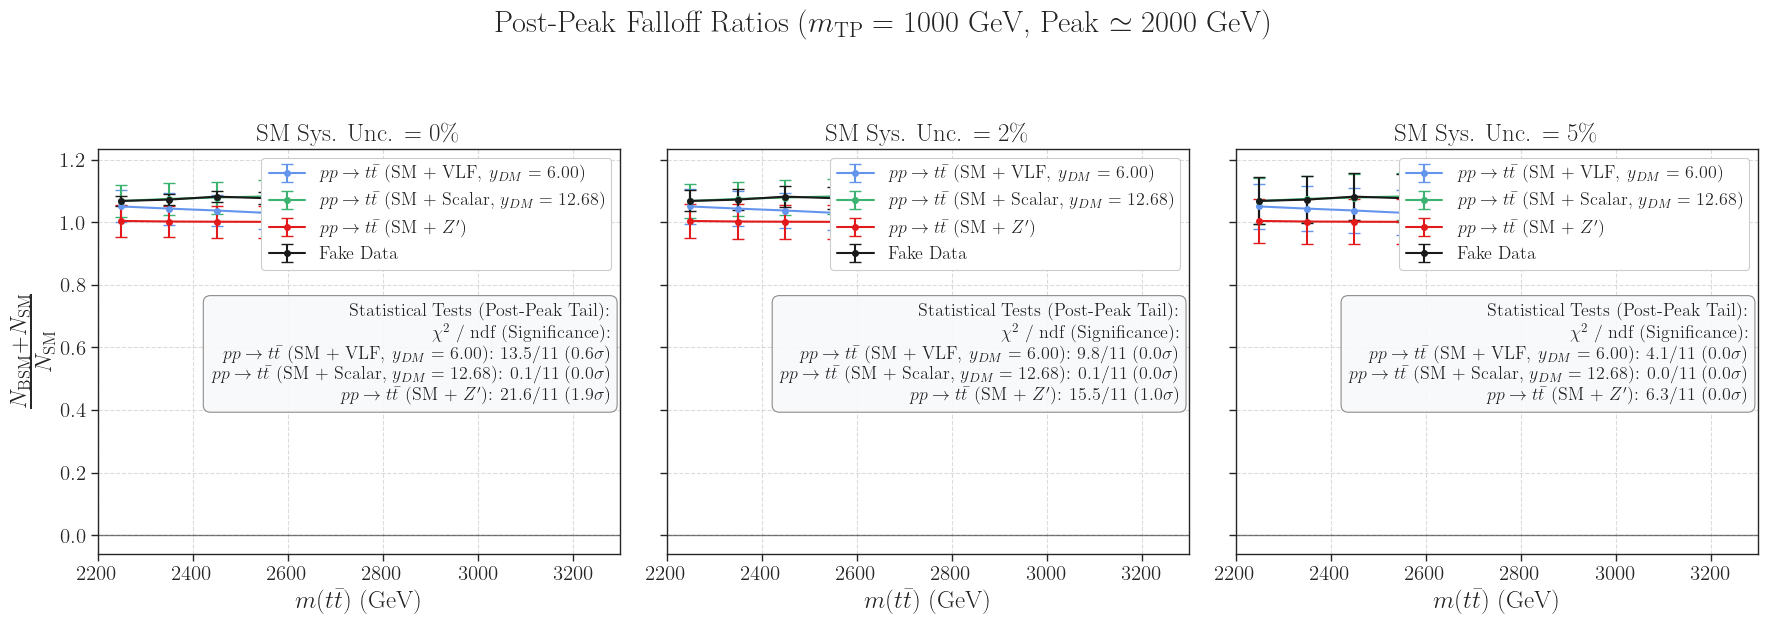


--- Significance Dictionary ---
{'$p p \\to t \\bar{t}$ (SM + VLF, $y_{DM} = 6.00$)': {0.0: np.float64(0.6298812603267281), 0.02: 0.0, 0.05: 0.0}, '$p p \\to t \\bar{t}$ (SM + Scalar, $y_{DM} = 12.68$)': {0.0: 0.0, 0.02: 0.0, 0.05: 0.0}, '$p p \\to t \\bar{t}$ (SM + $Z^\\prime$)': {0.0: np.float64(1.9158561061195545), 0.02: np.float64(0.9980294588666757), 0.05: 0.0}}


In [145]:
mTP = 1000.0 #GeV
n_bp = -2
n_ap = 13
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(f"Peak bin starts at: {bins[b_peak]}")

# Define the SM systematic uncertainties we want to plot
sm_errs_list = [0.0, 0.02, 0.05]

# --- ADDED: Initialize the dictionary to hold our results ---
model_significances_sm_signal = {}

# Create a 1x3 grid of subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# We will loop over the systematic uncertainties and fill each subplot
for idx, current_sm_err in enumerate(sm_errs_list):
    ax = axes[idx]
    
    # -----------------------------------------------------------------
    # 1. Recalculate Fake Data Error for this specific systematic
    # -----------------------------------------------------------------
    hErr_sm_current = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (current_sm_err * h_sm)**2)
    fake_err_current = np.sqrt(stat_variance_obs + hErr_sm_current**2)
    bsm_histsErr[-1] = fake_err_current
    print(len(bsm_errs), len(bsm_hists))
    err_bsm_rel = np.nan_to_num(np.array(bsm_histsErr) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm_current / h_sm)

    bsm_ratio_errs = np.abs(bsm_ratios) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    # -----------------------------------------------------------------
    # 2. Compute Ratios for this systematic
    # -----------------------------------------------------------------
    ratios = []
    ratios_err = []
    for i_hist, h in enumerate(bsm_ratios):
        aux = []
        err = []
        for j in range(b_peak-n_bp, b_peak + n_ap):
            A = h[j]
            B = 1.0
            errA = bsm_ratio_errs[i_hist][j]
            errB = 0
            
            val = A / B if B != 0 else 0
            aux.append(val)
            
            if A != 0 and B != 0:
                safe_err = abs(val) * np.sqrt((errA / A)**2 + (errB / B)**2)
            else:
                safe_err = 0.0
            err.append(safe_err)
            
        ratios.append(aux)
        ratios_err.append(err)

    # -----------------------------------------------------------------
    # 3. Statistical Tests
    # -----------------------------------------------------------------
    fake_ratio = np.array(ratios[-1])
    fake_ratio_err = np.array(ratios_err[-1])
    
    valid_fake_ratio = fake_ratio
    valid_fake_err = fake_ratio_err

    stats_lines = [
        "Statistical Tests (Post-Peak Tail):",
        r"$\chi^2$ / ndf (Significance):"
    ]

    for k in range(len(ratios) - 1): # Skip the last element (Fake Data)
        hyp_ratio = np.array(ratios[k])
        hyp_err = np.array(ratios_err[k])
        name = bsm_labels[k]
        
        total_variance = valid_fake_err**2 + hyp_err**2
        
        valid_mask = total_variance > 0
        ndf = np.sum(valid_mask)
        
        if ndf > 0:
            chi2_val = np.sum((valid_fake_ratio[valid_mask] - hyp_ratio[valid_mask])**2 / total_variance[valid_mask])
            p_value = stats.chi2.sf(chi2_val, ndf)
            
            if p_value >= 0.5:
                z_score = 0.0
            else:
                z_score = stats.norm.isf(max(p_value, 1e-55))
        else:
            chi2_val, z_score = 0.0, 0.0
        
        # --- ADDED: Save the results directly into our dictionary ---
        clean_name = name.strip() # Remove any accidental leading/trailing spaces
        if clean_name not in model_significances_sm_signal:
            model_significances_sm_signal[clean_name] = {} # Create a sub-dictionary for the model if it doesn't exist
            
        model_significances_sm_signal[clean_name][current_sm_err] = z_score #chi2_val/ndf
        
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    stats_text = "\n".join(stats_lines)

    # -----------------------------------------------------------------
    # 4. Plotting
    # -----------------------------------------------------------------
    x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak-n_bp, b_peak + n_ap)]

    for k in range(len(ratios)):
        label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
        color = bsm_colors[k] if 'bsm_colors' in locals() else None
        
        ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                    capsize=4, label=label, color=color, markersize=4, linewidth=1.5)
    
    # Increase axis label sizes
    ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=18)
    if idx == 0:
        ax.set_ylabel(r'$\frac{N_{\mathrm{BSM}} + N_{\mathrm{SM}}}{N_{\mathrm{SM}}}$', fontsize=24)
        
    # Increase subplot title size
    ax.set_title(r'SM Sys. Unc. = {:.0f}\%'.format(current_sm_err * 100), fontsize=18)
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Make the tick labels (numbers on the axes) larger
    ax.tick_params(axis='both', which='major', labelsize=15)

    # Annotations
    ax.legend(fontsize=13, framealpha=1.0, loc='upper right')

    ax.text(0.98, 0.62, stats_text, 
            transform=ax.transAxes,      
            fontsize=13,
            verticalalignment='top',         
            horizontalalignment='right',     
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

fig.suptitle(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=22, y=1.05)

plt.tight_layout()
#plt.savefig('Post_Peak_Falloff_SideBySide.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------
# 5. Accessing your saved variable
# -----------------------------------------------------------------
print("\n--- Significance Dictionary ---")
print(model_significances_sm_signal)

# Example of how to access a specific value later:
# vlf_5percent_sig = model_significances.get('VLF', {}).get(0.05, 0.0)

Matched 'VLF' -> Ratios: [np.float64(15.03338688588973), nan, nan]
Matched 'Scalar' -> Ratios: [nan, nan, nan]
Matched '$Z^\prime$' -> Ratios: [np.float64(6.260714580728858), np.float64(3.682907522019482), nan]


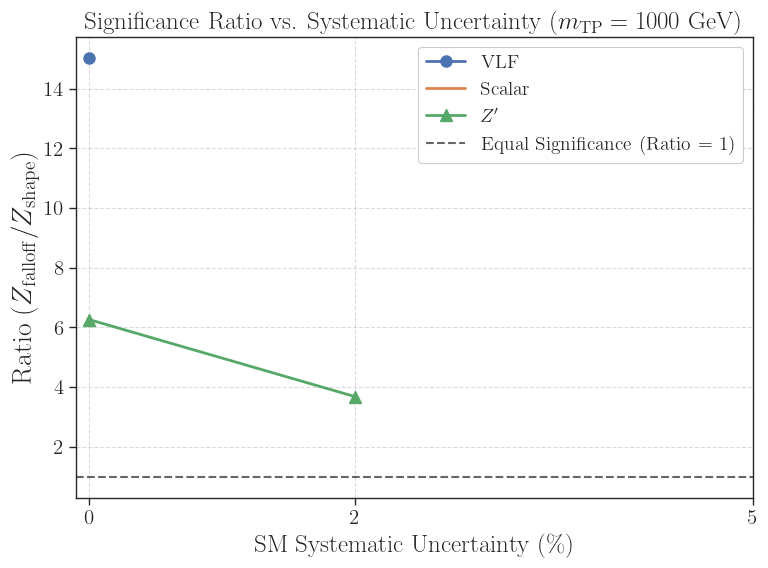

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# Get the systematic errors from the first available model
first_model = list(model_significances.keys())[0]
sm_errs = sorted(list(model_significances[first_model].keys()))
sm_errs_pct = [err * 100 for err in sm_errs] 

fig, ax = plt.subplots(figsize=(8, 6))
markers = ['o', '', '^', 'd', 'v']

lines_plotted = 0 

for i, sig_key in enumerate(model_significances.keys()):
    # 1. Identify the core model name in the first dictionary
    if 'VLF' in sig_key:
        core_name = 'VLF'
    elif 'Scalar' in sig_key:
        core_name = 'Scalar'
    elif r'$Z^\\prime$' in sig_key or r"$Z^\prime$" in sig_key:
        core_name = r'$Z^\prime$'
    else:
        continue # Skip if we can't identify it

    # 2. Find the matching key in the SM+Signal dictionary
    matched_sm_key = None
    for sm_key in model_significances_sm_signal.keys():
        if core_name in sm_key:
            matched_sm_key = sm_key
            break
            
    # 3. If we found a match, calculate ratios and plot
    if matched_sm_key:
        ratios = []
        for err in sm_errs:
            z_sig = model_significances[sig_key].get(err, 1.0)
            z_sm_sig = model_significances_sm_signal[matched_sm_key].get(err, 1.0)
            
            # Safe division
            if z_sm_sig > 0:
                ratio = z_sig / z_sm_sig
            else:
                ratio = np.nan
                
            ratios.append(ratio)
            
        print(f"Matched '{core_name}' -> Ratios: {ratios}")
        
        # Plot using the clean core_name for a nicer legend
        ax.plot(sm_errs_pct, ratios, marker=markers[i % len(markers)], 
                linewidth=2, markersize=8, label=core_name)
        lines_plotted += 1
    else:
        print(f"WARNING: Could not find a match for '{core_name}' in the SM+Signal dictionary!")

# --- Formatting the Plot ---
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Equal Significance (Ratio = 1)')

ax.set_xlabel(r'SM Systematic Uncertainty (\%)', fontsize=18)
ax.set_ylabel(r'Ratio $\left( Z_{\mathrm{falloff}} / Z_{\mathrm{shape}} \right)$', fontsize=20)
ax.set_title(r'Significance Ratio vs. Systematic Uncertainty ($m_{\mathrm{TP}} = 1000$ GeV)', fontsize=18)

ax.grid(True, linestyle='--', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xticks(sm_errs_pct) 


# Only draw legend if we plotted lines
if lines_plotted > 0:
    ax.legend(fontsize=14, loc='best', framealpha=1.0)

plt.tight_layout()
#plt.savefig('Significance_Ratio_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) 

yDM_S = np.sqrt(7.0**2 * tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(7.0**2 *tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) - np.sum(h_sm[tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )- np.sum(h_sm[tail_mask]) 
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) - np.sum(h_sm[tail_mask]) 

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

In [ ]:
mTP = 500.0 #GeV
n_bp = 20
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(bins[b_peak])
ratios = []

ratios_err = []

ratios = []
ratios_err = []

# Computing the ratios
for i, h in enumerate(bsm_hists):
    aux = []
    err = []
    for j in range(b_peak , b_peak + n_bp):
        A = h[j]
        B = h[b_peak]
        errA = bsm_errs[i][j]
        errB = bsm_errs[i][b_peak]
        
        aux.append(A / B)
        
        # Safe propagation: avoids dividing by zero if the tail crosses zero
        safe_err = np.sqrt((errA / B)**2 + (A * errB / (B**2))**2)
        err.append(safe_err)
        
    ratios.append(aux)
    ratios_err.append(err)

# ==========================================
# Plotting the ratios for each model
# ==========================================

# Calculate the bin centers for the x-axis
x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak , b_peak + n_bp)]

fig, ax = plt.subplots(figsize=(8, 6))

# Loop over the calculated ratios to plot them
for k in range(len(ratios)):
    label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
    color = bsm_colors[k] if 'bsm_colors' in locals() else None
    
    ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                capsize=4, label=label, color=color, markersize=4, linewidth=1.5)
ax.text(0.98, 0.72, rf'SM Uncertainty: {sm_err*100:.1f}\%', 
        transform=ax.transAxes,      # Use axis coordinates instead of mass data coordinates
        fontsize=12, 
        verticalalignment='top',     # Anchor the text from its top edge
        horizontalalignment='right', # Anchor the text from its right edge
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

# Formatting the plot to match the style of your previous physics plots
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=16)
ax.set_title(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=14)

# Adding a horizontal line at 0 so you can clearly see the negative interference crossing!
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, framealpha=1.0)
#ax.set_yscale('log')
plt.tight_layout()
#plt.savefig('Post_Peak_Falloff.png', dpi=300)
plt.show()

In [ ]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.05 # 5% SM Systematic Uncertainty

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 4500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Extract final Expected SM Events
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    
    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 1.000e+00}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) # Error includes SM systematics
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)
                      
        # --- Propagating Error for Z' Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale # APPLY LUMINOSITY SCALING
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # Statistical uncertainty of observed data is just sqrt(N)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')

    # --- Propagating error for Ratio ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs / h_sm
        err_bsm_stat = np.sqrt(bsm_histsErr[-1])
        
        ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data ', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3, density=False
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_histsErr[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )        
    
       
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    # Dynamically build hypotheses list containing: (Name, Hist, Error)
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # ---------------------------------------------------------
    # RESTRICT TO SIGNAL REGION (1700 GeV to 3000 GeV)
    # ---------------------------------------------------------
    #mass_mask = (x >= 2000.0) & (x <= 4500.0)
    mass_mask = (x >= 1800.0) & (x <= 2200.0)
    # Ensure we only use bins that are inside the mass window AND have expected SM events
    valid_mask = (h_sm > 0) & mass_mask
    ndf = np.sum(valid_mask)
    
    # Update text to reflect the restricted range
    stats_lines = []
    
    
        
    stats_lines.append("")
    stats_lines.append(r"$\chi^2$ / ndf (1.7 - 3.0 TeV):")
    
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        
        # Total Variance = Var(FakeData) + Var(Hypothesis)
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        
        # Calculate Chi2 (only where variance > 0 to be safe)
        safe_variance_mask = total_variance > 0
        
        # Calculate chi2 only for the valid bins in the Signal Region
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        
        # Calculate Significance
        p_value = stats.chi2.sf(chi2_val, ndf) if ndf > 0 else 1.0
        
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-300))
            
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    # Combine into one text string
    stats_text = "\n".join(stats_lines)

    # Place the stats text box on the plot
    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, 
                  verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
   ############
    #  SUBPLOT #
    ############
    
    # The reference denominator is the Fake Data (the last item in the lists)
    fake_data_yield = bsm_hists[-1]
    fake_data_err = bsm_histsErr[-1]

    # Loop over all theoretical models (everything except the Fake Data itself)
    for k in range(len(bsm_hists) - 1):
        model_yield = bsm_hists[k]
        model_err = bsm_histsErr[k]
        
        with np.errstate(divide='ignore', invalid='ignore'):
            # Ratio = Model / Fake Data
            ratio = model_yield / fake_data_yield
            
            # Relative errors
            rel_model_err = model_err / model_yield
            rel_fake_err = fake_data_err / fake_data_yield
            
            # Propagate total error for the ratio
            ratio_err = np.abs(ratio) * np.sqrt(rel_model_err**2 + rel_fake_err**2)
            
            # Safely mask out bins where Fake Data or the Model drops to zero
            zero_mask = (fake_data_yield <= 0) | (model_yield <= 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        axarr[1].errorbar(x, ratio, yerr=ratio_err, color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, ratio, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot configurations
    axarr[1].axhline(y=1.0, color='k', linestyle='--', alpha=0.7) 
    
    # Updated Y-axis label to match the new math
    axarr[1].set_ylabel(r'$\frac{\mathrm{Model}}{\mathrm{Fake\ Data}}$', fontsize=16) 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
    axarr[1].grid(True, linestyle=':', alpha=0.6)
    
    # Depending on how far the Z' drops, you may need to tweak this symlog or change to linear
    axarr[1].set_yscale('symlog', linthresh = 1.2)
    
    plt.tight_layout()
    #plt.savefig('Dists_comparison.png')
    plt.show()

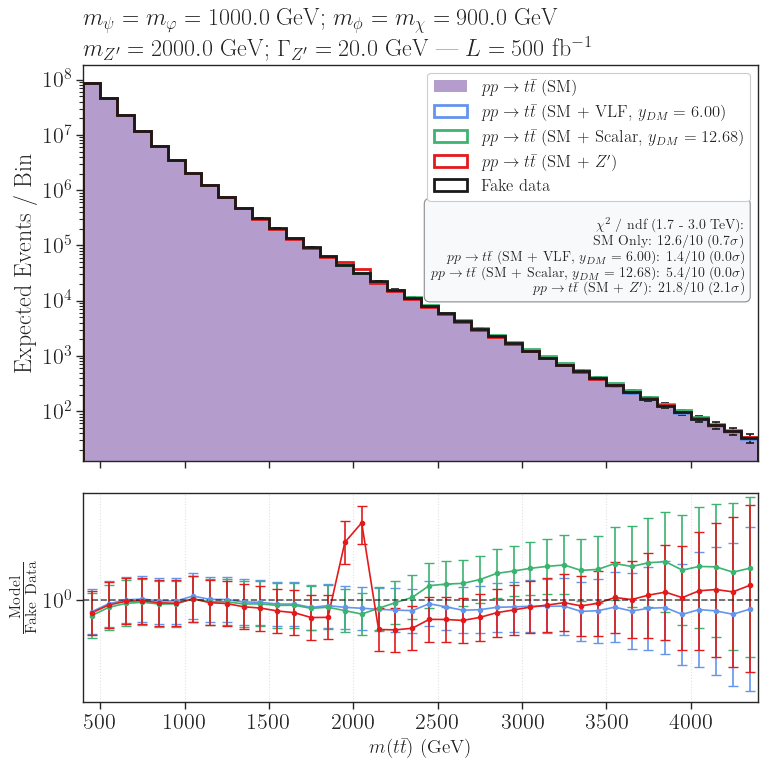

In [414]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.05 # 5% SM Systematic Uncertainty

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 4500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Extract final Expected SM Events
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    
    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 1.000e+00}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) # Error includes SM systematics
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)
                      
        # --- Propagating Error for Z' Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale # APPLY LUMINOSITY SCALING
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # Statistical uncertainty of observed data is just sqrt(N)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')

    # --- Propagating error for Ratio ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs / h_sm
        err_bsm_stat = np.sqrt(bsm_histsErr[-1])
        
        ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data ', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3, density=False
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_histsErr[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )        
    
       
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    # Dynamically build hypotheses list containing: (Name, Hist, Error)
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # ---------------------------------------------------------
    # RESTRICT TO SIGNAL REGION (1700 GeV to 3000 GeV)
    # ---------------------------------------------------------
    #mass_mask = (x >= 2000.0) & (x <= 4500.0)
    mass_mask = (x >= 2000.0) & (x <= 3000.0)
    # Ensure we only use bins that are inside the mass window AND have expected SM events
    valid_mask = (h_sm > 0) & mass_mask
    ndf = np.sum(valid_mask)
    
    # Update text to reflect the restricted range
    stats_lines = []
    
    
        
    stats_lines.append("")
    stats_lines.append(r"$\chi^2$ / ndf (1.7 - 3.0 TeV):")
    
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        
        # Total Variance = Var(FakeData) + Var(Hypothesis)
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        
        # Calculate Chi2 (only where variance > 0 to be safe)
        safe_variance_mask = total_variance > 0
        
        # Calculate chi2 only for the valid bins in the Signal Region
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        
        # Calculate Significance
        p_value = stats.chi2.sf(chi2_val, ndf) if ndf > 0 else 1.0
        
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-300))
            
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    # Combine into one text string
    stats_text = "\n".join(stats_lines)

    # Place the stats text box on the plot
    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, 
                  verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
   ############
    #  SUBPLOT #
    ############
    
    # The reference denominator is the Fake Data (the last item in the lists)
    fake_data_yield = bsm_hists[-1]
    fake_data_err = bsm_histsErr[-1]

    # Loop over all theoretical models (everything except the Fake Data itself)
    for k in range(len(bsm_hists) - 1):
        model_yield = bsm_hists[k]
        model_err = bsm_histsErr[k]
        
        with np.errstate(divide='ignore', invalid='ignore'):
            # Ratio = Model / Fake Data
            ratio = model_yield / fake_data_yield
            
            # Relative errors
            rel_model_err = model_err / model_yield
            rel_fake_err = fake_data_err / fake_data_yield
            
            # Propagate total error for the ratio
            ratio_err = np.abs(ratio) * np.sqrt(rel_model_err**2 + rel_fake_err**2)
            
            # Safely mask out bins where Fake Data or the Model drops to zero
            zero_mask = (fake_data_yield <= 0) | (model_yield <= 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        axarr[1].errorbar(x, ratio, yerr=ratio_err, color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, ratio, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot configurations
    axarr[1].axhline(y=1.0, color='k', linestyle='--', alpha=0.7) 
    
    # Updated Y-axis label to match the new math
    axarr[1].set_ylabel(r'$\frac{\mathrm{Model}}{\mathrm{Fake\ Data}}$', fontsize=16) 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
    axarr[1].grid(True, linestyle=':', alpha=0.6)
    
    # Depending on how far the Z' drops, you may need to tweak this symlog or change to linear
    axarr[1].set_yscale('symlog', linthresh = 1.2)
    
    plt.tight_layout()
    #plt.savefig('Dists_comparison.png')
    plt.show()


--- Ratio Chi-Squared Test (2500 - 3000 GeV) ---
vs SM Only         -> Chi2 =  29.8 | Z = 3.93 sigma
vs SM + VLF        -> Chi2 =   4.9 | Z = 0.00 sigma
vs SM + Scalar     -> Chi2 =  46.7 | Z = 5.48 sigma
vs SM + $Z^\prime$ -> Chi2 =  28.1 | Z = 3.74 sigma
-----------------------------------------------------------------



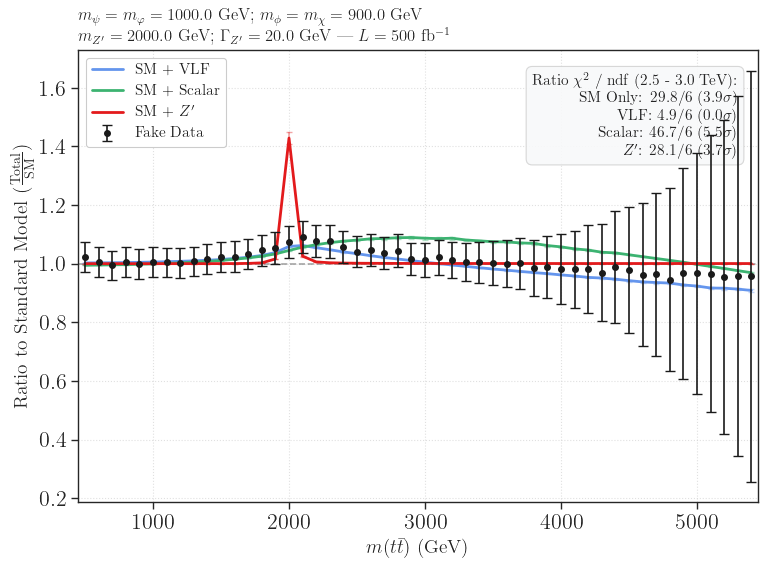

In [384]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb
sm_err = 0.05 # 5% SM Systematic Uncertainty

# Mass window for Chi-Squared test
chi2_mass_min = 2500.0
chi2_mass_max = 3000.0

# Loop over the masses configurations
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    # CHANGED: Single axis plot instead of two subplots
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=0.90)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(450., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ########################
    # Data Processing Loop #
    ########################
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)

    # ==========================================
    # NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        model_name = str(np.atleast_1d(d['model'])[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        display_name = model_name.replace('1-loop ', '')
        label = r'SM + %s' % display_name
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        model_z = str(np.atleast_1d(d['model'])[0])
        
    if len(data_Z) > 0:
        label_z = r'SM + $Z^\prime$'
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    # ==========================================
    # Fake Data
    # ==========================================
    h_fake = np.zeros(len(bins)-1)
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale 
        
    N_obs = h_fake / (n + 1)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    bsm_labels.append('Fake Data')
    bsm_colors.append('k') # Black for fake data

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs / h_sm
        err_bsm_stat = np.sqrt(stat_variance_obs)
        
        # Propagating Ratio error for Fake data
        ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (ratio)**2 * hErr_sm**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    ######################################################
    #  Statistical Tests (Ratio Chi-Squared)             #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2 
    
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # ---------------------------------------------------------
    # MASK: RESTRICT CHI-SQUARE TO SPECIFIC MASS INTERVAL
    # ---------------------------------------------------------
    mass_mask = (x >= chi2_mass_min) & (x <= chi2_mass_max)
    valid_mask = (h_sm > 0) & mass_mask
    ndf = np.sum(valid_mask)
    
    print(f"\n--- Ratio Chi-Squared Test ({chi2_mass_min:.0f} - {chi2_mass_max:.0f} GeV) ---")
    stats_lines = [rf"Ratio $\chi^2$ / ndf ({chi2_mass_min/1000:.1f} - {chi2_mass_max/1000:.1f} TeV):"]
    
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        B = h_sm[valid_mask]
        
        var_O = fake_obs_variance[valid_mask]
        var_B = hErr_sm[valid_mask]**2
        var_E_pure = np.maximum(0, hyp_err[valid_mask]**2 - var_B)
        
        R_diff = (O - E) / B
        var_R_diff = (1.0 / B**2) * (var_O + var_E_pure) + ((O - E)**2 / B**4) * var_B
        
        safe_variance_mask = var_R_diff > 0
        chi2_val = np.sum(R_diff[safe_variance_mask]**2 / var_R_diff[safe_variance_mask])
        
        p_value = stats.chi2.sf(chi2_val, ndf) if ndf > 0 else 1.0
        z_score = 0.0 if p_value >= 0.5 else stats.norm.isf(max(p_value, 1e-15))
            
        print(f"vs {name:15s} -> Chi2 = {chi2_val:5.1f} | Z = {z_score:4.2f} sigma")
        stats_lines.append(f"{name.replace('SM + ', '')}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    print("-" * 65 + "\n")
    stats_text = "\n".join(stats_lines)

    ################
    #  Plotting    #
    ################
    
    # Draw a reference line at Ratio = 1.0 (Standard Model expectation)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7) 
    
    # Plot all the stored ratios!
    for k, r in enumerate(bsm_ratios):
        # We plot Fake Data as points, and Theory Models as lines with shaded error bands (or just lines)
        if "Fake Data" in bsm_labels[k]:
            ax.errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='o', ms=4, capsize=3.5, label=bsm_labels[k], zorder=10)
        else:
            # Connect the theory dots with a line
            ax.plot(x, r, color=bsm_colors[k], label=bsm_labels[k], linewidth=2, zorder=5)
            # Add error bars to the theory curves too
            ax.errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='none', alpha=0.4, capsize=2)

    # Place the stats text box on the plot
    ax.text(0.97, 0.95, stats_text, 
            transform=ax.transAxes,      
            fontsize=11, 
            verticalalignment='top',     
            horizontalalignment='right', 
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='lightgray', alpha=0.9))

    #################
    #  Plot configs #
    #################
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0

    ax.legend(framealpha=1.0, ncol=1, loc='upper left', fontsize=11)
    ax.set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left', fontsize=12
    )
    
    ax.set_xlim(bins.min(), bins.max())
    ax.set_ylabel(r'Ratio to Standard Model ($\frac{\mathrm{Total}}{\mathrm{SM}}$)', fontsize=14) 
    ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
    ax.grid(True, which="both", linestyle=':', alpha=0.6)
    
    # Optional: Log scale configuration for the Ratio axis
    #ax.set_yscale('symlog', linthresh = 1.2)
    #ax.set_ylim([-0.003, 0.3]) # Adjust if needed for your specific limits
    
    plt.tight_layout()
    #plt.savefig('Ratio_Only_Comparison.png', dpi=300)
    plt.show()

1-loop VLF 1-loop VLF
1-loop Scalar 1-loop Scalar


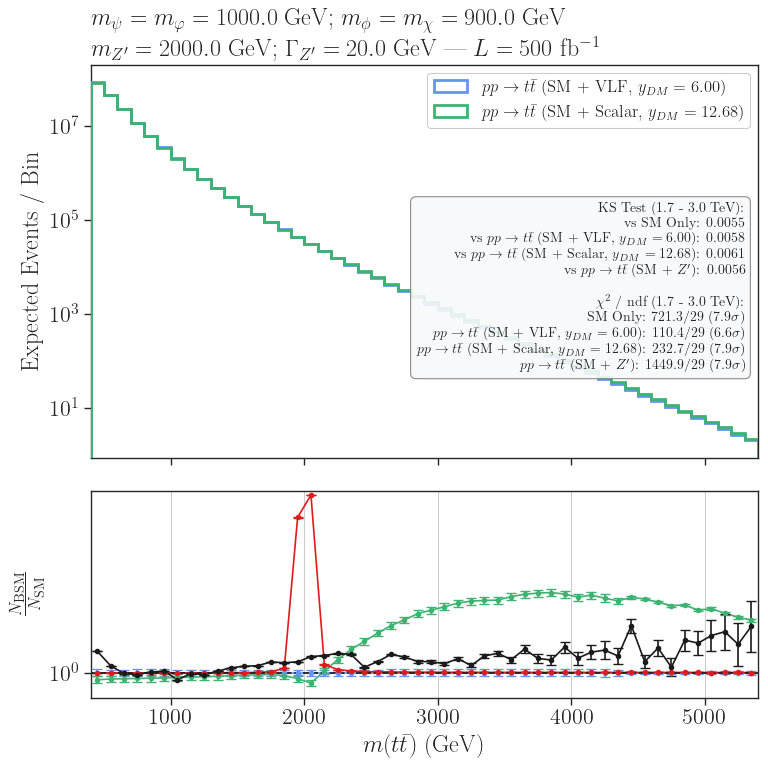

In [385]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.0 # 5% SM Systematic Uncertainty

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Extract final Expected SM Events
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    
    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)
    
    #axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
     #             color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
      #            linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 1.000e+00}
    for j in range(0, len(selected), 2):
        print(selected[j]['model'], selected[j+1]['model'])
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) # Error includes SM systematics
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / bsm_hists[0]
            err_bsm_stat = np.sqrt(bsm_histsErr[0]**2)
            
            ratio_err = (1.0 / bsm_hists[0]) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / bsm_hists[0])**2 * bsm_histsErr[0]**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        #axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
         #             color=color_z, alpha=1.0, histtype='step', density=False,
          #            linewidth=2, fill=False, zorder=3)
                      
        # --- Propagating Error for Z' Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale # APPLY LUMINOSITY SCALING
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # Statistical uncertainty of observed data is just sqrt(N)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')

    # --- Propagating error for Ratio ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs /  bsm_hists[0]
        err_bsm_stat = np.sqrt(bsm_histsErr[0])
        
        ratio_err = (1.0 / bsm_hists[0]) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw /  bsm_hists[0])**2 * bsm_histsErr[0]**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    #axarr[0].hist(
     #   bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data ', bins=bins,
      #  color='k', alpha=1.0, histtype='step', 
       # linewidth=2, fill=False, zorder=3, density=False
    #)
    
    #axarr[0].errorbar(
     #   x, np.abs(bsm_hists[-1]), yerr=bsm_histsErr[-1], color='k', 
      #  fmt='none', capsize=3, capthick=1.2, barsabove=True
    #)        
    
       
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    # Dynamically build hypotheses list containing: (Name, Hist, Error)
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # ---------------------------------------------------------
    # RESTRICT TO SIGNAL REGION (1700 GeV to 3000 GeV)
    # ---------------------------------------------------------
    mass_mask = (x >= 00.0) & (x <= 3300.0)
    
    # Ensure we only use bins that are inside the mass window AND have expected SM events
    valid_mask = (h_sm > 0) & mass_mask
    ndf = np.sum(valid_mask)
    
    # Update text to reflect the restricted range
    stats_lines = ["KS Test (1.7 - 3.0 TeV):"]
    
    # 1. KS Test Calculation
    fake_yield = fake_obs[valid_mask]
    cdf_fake = np.cumsum(fake_yield)
    cdf_fake_norm = cdf_fake / cdf_fake[-1] if len(cdf_fake) > 0 and cdf_fake[-1] != 0 else cdf_fake
    
    for name, hyp_hist, _ in hypotheses:
        hyp_yield = hyp_hist[valid_mask]
        cdf_hyp = np.cumsum(hyp_yield)
        cdf_hyp_norm = cdf_hyp / cdf_hyp[-1] if len(cdf_hyp) > 0 and cdf_hyp[-1] != 0 else cdf_hyp
        
        D_statistic = np.max(np.abs(cdf_hyp_norm - cdf_fake_norm)) if len(cdf_fake_norm) > 0 else 0
        stats_lines.append(f"vs {name}: {D_statistic:.4f}")
        
    stats_lines.append("")
    stats_lines.append(r"$\chi^2$ / ndf (1.7 - 3.0 TeV):")
    
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        
        # Total Variance = Var(FakeData) + Var(Hypothesis)
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        
        # Calculate Chi2 (only where variance > 0 to be safe)
        safe_variance_mask = total_variance > 0
        
        # Calculate chi2 only for the valid bins in the Signal Region
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        
        # Calculate Significance
        p_value = stats.chi2.sf(chi2_val, ndf) if ndf > 0 else 1.0
        
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-15))
            
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    # Combine into one text string
    stats_text = "\n".join(stats_lines)

    # Place the stats text box on the plot
    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, 
                  verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
    ############
    #  SUBPLOT #
    ############
    
    for k, r in enumerate(bsm_ratios):
        axarr[1].errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    axarr[1].axhline(y=1.0, color='k', linestyle='--') 
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    #axarr[1].set_yticks(np.arange(0.95,1.2, 0.05))
    axarr[1].set_yscale('symlog', linthresh = 1.2)
    
    plt.tight_layout()
    #plt.savefig('Dists_comparison.png')
    plt.show()